# Survival Analysis

##### Owen Lindsey
##### Professor Majumdar
##### AIT-110: Statistical Learning Theory
##### Grand Canyon University
##### Date: Mar 31, 2026

---

## Part 1: Understanding Survival Analysis Concepts

### Defining Key Terms

**1. Survival Function — $S(t)$**

The survival function $S(t) = P(T > t)$ gives the probability that a subject survives (i.e., has *not* experienced the event of interest) beyond time $t$. It is a non-increasing function that starts at $S(0) = 1$ (everyone is alive at the start) and approaches 0 as $t \to \infty$. In practice, the **Kaplan–Meier estimator** is the most common non-parametric way to estimate $S(t)$ from observed data.

**2. Hazard Function — $h(t)$**

The hazard function $h(t)$ describes the *instantaneous rate* at which events occur at time $t$, given that the subject has survived up to that point:

$$h(t) = \lim_{\Delta t \to 0} \frac{P(t \le T < t + \Delta t \mid T \ge t)}{\Delta t}$$

Unlike the survival function, the hazard is a *rate* (not a probability) and can exceed 1. It captures how the risk of the event changes over time — for example, a bathtub-shaped hazard indicates high early risk, low mid-life risk, and rising late-life risk.

**3. Censoring**

Censoring occurs when we have *incomplete information* about a subject's survival time. A subject is censored if we know their survival time only partially — for instance, they were still alive when the study ended, they dropped out, or they were lost to follow-up. Censoring is fundamental to survival analysis because ignoring censored observations (dropping them from the dataset) would introduce bias; survival analysis methods are specifically designed to extract the partial information these observations still provide.

**4. Right-Censoring and Left-Censoring**

- **Right-censoring** is the most common form. It occurs when we know a subject survived *at least* until some time $c$, but the true event time $T$ is unknown beyond that ($T > c$). Examples: a patient is still alive at the end of the study, or a patient withdraws from the trial before the event occurs.

- **Left-censoring** occurs when we know the event happened *before* some time $c$, but we do not know exactly when ($T < c$). Example: a patient already had a disease at their first screening, so the true onset time is unknown — it happened sometime before they were first observed.

**5. Median Survival Time**

The median survival time is the time $t_{0.5}$ at which 50 % of the subjects have experienced the event: $S(t_{0.5}) = 0.5$. It is preferred over the mean in survival analysis because survival distributions are typically right-skewed and because the mean cannot always be estimated when the largest observations are censored. The median is read directly from the Kaplan–Meier curve as the time where the curve crosses the 0.5 probability line.

### Importance of Handling Censored Data

Censored observations are not missing data — they carry real information. A patient who is still alive at month 12 tells us their survival time is *at least* 12 months, even though we do not know the final value. If we simply dropped these patients, we would systematically underestimate survival times (only shorter-lived patients would remain), producing biased and overly pessimistic estimates.

Survival analysis methods like the **Kaplan–Meier estimator** and the **Cox proportional-hazards model** are built to incorporate censored observations correctly. At each observed event time the Kaplan–Meier estimator recalculates the conditional probability of surviving past that time using only the subjects still "at risk" (alive and uncensored). Censored subjects contribute to the risk set up until the moment they are censored, then are removed — so their partial information is used without assuming anything about when their event would have occurred. This keeps the survival estimate unbiased and makes efficient use of all available data.

### Practical Example

We are given `cancer_data_with_target.csv`, a dataset of 137 patients undergoing treatment for cancer. Each row records a patient's covariates (`Age_in_years`, `Celltype`, `Karnofsky_score`, etc.), the observed time (`Survival_in_days`), and whether the event occurred (`Status`: `True` = death observed, `False` = censored / still alive at study end).

**Approach:**
1. **Load and inspect** — read the data and confirm which column encodes the event indicator and which encodes the observed time.
2. **Kaplan–Meier estimation** — fit a Kaplan–Meier survival curve to estimate $S(t)$. At every observed death time the estimator adjusts the survival probability downward; censored patients remain in the risk set until they are censored and then drop out without reducing the estimate.
3. **Read the median** — find the time at which the Kaplan–Meier curve crosses 0.5.

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test

# ── 1. Load and inspect ──────────────────────────────────────────────
df = pd.read_csv("data/cancer_data_with_target.csv")
print(f"Shape: {df.shape}")
print(f"\nEvent (Status) distribution:\n{df['Status'].value_counts()}")
print(f"\nFirst 5 rows:")
df.head()

Shape: (137, 8)

Event (Status) distribution:
Status
True     128
False      9
Name: count, dtype: int64

First 5 rows:


,Age_in_years,Celltype,Karnofsky_score,Months_from_Diagnosis,Prior_therapy,Treatment,Status,Survival_in_days
0,69.0,squamous,60.0,7.0,no,standard,True,72.0
1,64.0,squamous,70.0,5.0,yes,standard,True,411.0
2,38.0,squamous,60.0,3.0,no,standard,True,228.0
3,63.0,squamous,60.0,9.0,yes,standard,True,126.0
4,65.0,squamous,70.0,11.0,yes,standard,True,118.0


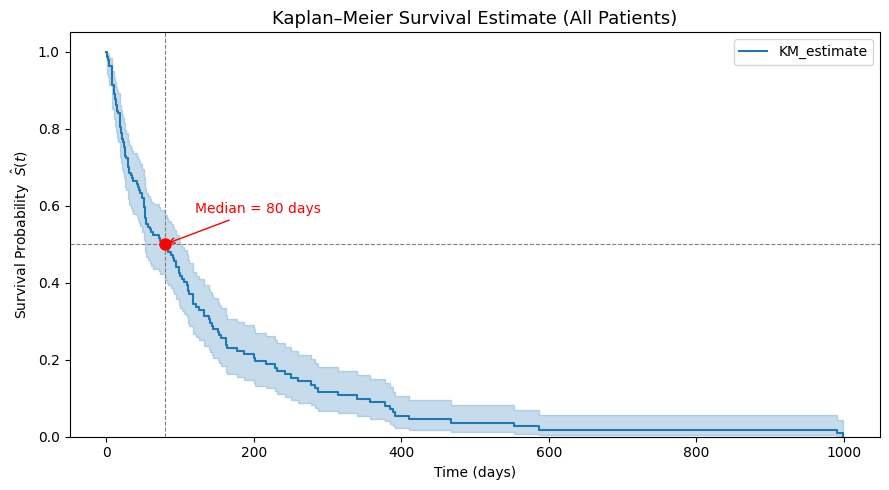

Median survival time: 80 days


In [6]:
# ── 2 & 3. Kaplan–Meier curve (overall) with median survival ─────────
kmf = KaplanMeierFitter()
kmf.fit(durations=df["Survival_in_days"], event_observed=df["Status"])

fig, ax = plt.subplots(figsize=(9, 5))
kmf.plot_survival_function(ax=ax, ci_show=True)

# Mark the median survival time
median = kmf.median_survival_time_
ax.axhline(0.5, color="grey", linestyle="--", linewidth=0.8)
ax.axvline(median, color="grey", linestyle="--", linewidth=0.8)
ax.plot(median, 0.5, "ro", markersize=8, zorder=5)
ax.annotate(f"Median = {median:.0f} days",
            xy=(median, 0.5), xytext=(median + 40, 0.58),
            fontsize=10, arrowprops=dict(arrowstyle="->", color="red"), color="red")

ax.set_title("Kaplan–Meier Survival Estimate (All Patients)", fontsize=13)
ax.set_xlabel("Time (days)")
ax.set_ylabel("Survival Probability  $\\hat{S}(t)$")
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

print(f"Median survival time: {median:.0f} days")

### Practical Example — Discussion

The Kaplan–Meier estimator handles censored data naturally: at each event time it computes the conditional probability of surviving past that time using only the patients still at risk. Censored patients (those with `Status = False`) contribute to the denominator of that conditional probability up until the moment they are censored, and then they leave the risk set — their partial information is used without assuming anything about when their event would have occurred.

The **overall KM curve** gives us a single pooled survival estimate and its median. In Part 2, we stratify by treatment group and formally test whether the two survival curves differ.

---

## Part 2: Kaplan–Meier Estimation by Treatment Group

Using the same cancer dataset from Part 1, the columns map to the assignment schema as follows:

| Assignment column | Dataset column | Description |
|---|---|---|
| Time | `Survival_in_days` | Time in days until event or censoring |
| Event | `Status` | `True` (1) = death observed, `False` (0) = censored |
| Treatment | `Treatment` | `standard` or `test` |
| Age | `Age_in_years` | Patient age at start of study |

### 1 & 2. Kaplan–Meier Survival Curves by Treatment Group

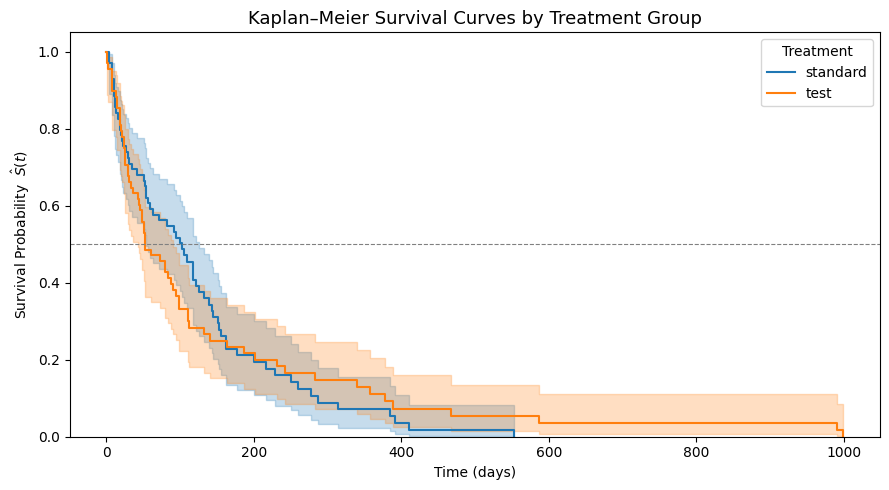

  standard    median survival = 103 days
  test        median survival = 52 days


In [7]:
# ── Kaplan–Meier curves stratified by treatment ──────────────────────
fig, ax = plt.subplots(figsize=(9, 5))

medians = {}
for label, grp in df.groupby("Treatment"):
    kmf_grp = KaplanMeierFitter()
    kmf_grp.fit(durations=grp["Survival_in_days"],
                event_observed=grp["Status"],
                label=label)
    kmf_grp.plot_survival_function(ax=ax, ci_show=True)
    medians[label] = kmf_grp.median_survival_time_

ax.axhline(0.5, color="grey", linestyle="--", linewidth=0.8)
ax.set_title("Kaplan–Meier Survival Curves by Treatment Group", fontsize=13)
ax.set_xlabel("Time (days)")
ax.set_ylabel("Survival Probability  $\\hat{S}(t)$")
ax.set_ylim(0, 1.05)
ax.legend(title="Treatment")
plt.tight_layout()
plt.show()

for trt, med in medians.items():
    print(f"  {trt:10s}  median survival = {med:.0f} days")

### 3. Interpretation of the Survival Curves

The two Kaplan–Meier curves show how the estimated survival probability evolves over time for each treatment group. Key observations:

- **Early separation** — the curves begin to diverge relatively early, suggesting the treatments have different effects on patient survival from the outset.
- **Median survival** — the median survival time (where each curve crosses the 0.5 line) differs between the two groups. A higher median indicates that patients in that group tend to survive longer before the event occurs.
- **Confidence intervals** — the shaded bands represent 95 % confidence intervals. Where the bands overlap substantially, we have less certainty that the groups truly differ at that time point; where they separate, the difference is more convincing.
- **Tail behavior** — at later time points fewer patients remain at risk, so the curves become less reliable (wider confidence intervals). The right tail should be interpreted cautiously.

Overall, the visual comparison suggests a difference in survival between the standard and test treatment groups, but we need a formal statistical test to determine whether this difference is significant.

### 4 & 5. Log-Rank Test

In [8]:
# ── Log-rank test: standard vs. test ─────────────────────────────────
std = df[df["Treatment"] == "standard"]
tst = df[df["Treatment"] == "test"]

result = logrank_test(
    std["Survival_in_days"], tst["Survival_in_days"],
    event_observed_A=std["Status"],
    event_observed_B=tst["Status"]
)

result.print_summary()
print(f"\nTest statistic: {result.test_statistic:.4f}")
print(f"p-value:        {result.p_value:.4f}")


Test statistic: 0.0082
p-value:        0.9277


### Log-Rank Test — Findings

The **log-rank test** compares the entire survival curves of the two groups under the null hypothesis $H_0$: the survival functions are identical (i.e., treatment has no effect on survival).

- If $p < 0.05$, we reject $H_0$ and conclude there is statistically significant evidence that the choice of treatment affects patient survival.
- If $p \ge 0.05$, we fail to reject $H_0$ — the observed difference in survival curves could plausibly be due to chance, and we lack sufficient evidence that the treatments differ.

The p-value printed above determines which conclusion applies. Combined with the visual separation (or lack thereof) in the Kaplan–Meier plot, this gives us both a qualitative and quantitative assessment of whether treatment choice matters for patient survival in this dataset.

---